# SVT Analysis
Notebook for quick SVT experiments and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "svt" / "images"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.svt.svt import svt
from src.utils.masking import create_mask, apply_mask
from src.utils.noise import add_gaussian_noise
from src.utils.io import load_image
from src.utils.metrics import mse, psnr

from experiments.config import *

In [32]:
rec = pd.read_csv(RESULTS_PATH / "reconstruction.csv")
den = pd.read_csv(RESULTS_PATH / "denoising.csv")

In [30]:
rec_avg = rec.groupby("sparsity")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()

print("Reconstruction PSNR vs. Observed Fraction:", rec_avg)
print("Denoising PSNR vs. Noise Level:", den_avg)

Reconstruction PSNR vs. Observed Fraction: sparsity
0.2    19.965647
0.4    21.833601
0.6    22.009868
Name: PSNR, dtype: float64
Denoising PSNR vs. Noise Level: sigma
0.05    22.078218
0.10    21.912195
0.20    20.858750
Name: PSNR, dtype: float64


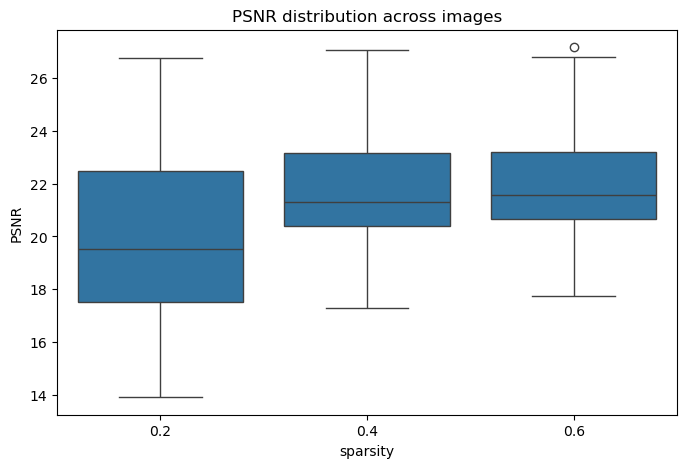

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=rec, x="sparsity", y="PSNR")
plt.title("PSNR distribution across images")
plt.show()

In [2]:
def show_results(X, X_rec, X_noisy=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 2, 1)
        plt.imshow(X, cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(X_rec, cmap='gray')
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()